<a href="https://colab.research.google.com/github/WagnerZS/Projeto-de-Integracao-de-Dados-de-Criminalidade-e-Meteorologia-em-Passo-Fundo/blob/main/Projeto_de_Integra%C3%A7%C3%A3o_de_Dados_de_Criminalidade_e_Meteorologia_em_Passo_Fundo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Preparação do ambiente com importações e variáveis

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
from IPython.utils import encoding

In [4]:
pastaCriminal = '/content/drive/MyDrive/Trabalho Criminalidade e Meteorologia/Dados criminais'
pastaMeteorologia = '/content/drive/MyDrive/Trabalho Criminalidade e Meteorologia/Dados meteorologicos'

##Etapa 1 e 2- Coleta de dados, concatenação dos dados de criminalidade

In [14]:
#Leitura do CSV local
#dfOcorrencia2021 = pd.read_csv('ocorrencias-2021.csv', delimiter=';', encoding='latin1')
#Leitura do CSV pelo Drive
dfOcorrencia2021 = pd.read_csv(pastaCriminal + '/ocorrencias-2021.csv', delimiter=';', encoding='latin1')
dfOcorrencia2021.drop(columns=dfOcorrencia2021.columns[13:], inplace=True)
dfOcorrencia2021.rename(columns={
    'Sequência': 'sequencia',
    'Quantidade Vítimas': 'quantidade_vitimas',
    'Idade Vítima': 'idade_vitimas',
    'Sexo Vítima': 'sexo_vitimas',
    'Cor Vítima': 'cor_vitimas',
    'Data Fato': 'data',
    'Hora Fato': 'hora_fato',
    'Grupo Fato': 'grupo_fato',
    'Tipo Enquadramento': 'tipo_enquadramento',
    'Tipo Fato': 'tipo_fato',
    'Municipio Fato': 'municipio_fato',
    'Local Fato': 'local_fato',
    'Bairro': 'bairro'
}, inplace=True)

dfOcorrencia2021.drop('sequencia', axis=1, inplace=True)

dfOcorrencia2021 = dfOcorrencia2021[dfOcorrencia2021.municipio_fato.str.upper() == 'PASSO FUNDO'].copy()

dfOcorrencia2021.quantidade_vitimas = pd.to_numeric(dfOcorrencia2021.quantidade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2021.idade_vitimas = pd.to_numeric(dfOcorrencia2021.idade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2021.data = pd.to_datetime(dfOcorrencia2021.data, format='%d/%m/%Y', errors='coerce')

dfOcorrencia2021.info()

/tmp/ipykernel_16643/2332515926.py:4: DtypeWarning: Columns (23,24,26,27,29,30,32,33,35,36,38,39,41,42,44,45,47,48,50,51,53,54,56,57,59,60,62,63,65,66,68,69,71,72,74,75,77,78,80,81,83,84,86,87,89,90,92,93,95,96,98,99,101,102,104,105,107,108,110,111,113,114,116,117,119,120,122,123,125,126,128,129,131,132,134,135) have mixed types. Specify dtype option on import or set low_memory=False.
  dfOcorrencia2021 = pd.read_csv(pastaCriminal + '/ocorrencias-2021.csv', delimiter=';', encoding='latin1')


<class 'pandas.core.frame.DataFrame'>
Index: 3612 entries, 6 to 166096
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data                3612 non-null   datetime64[ns]
 1   hora_fato           3612 non-null   object        
 2   grupo_fato          3612 non-null   object        
 3   tipo_enquadramento  3612 non-null   object        
 4   tipo_fato           3612 non-null   object        
 5   municipio_fato      3612 non-null   object        
 6   local_fato          3612 non-null   object        
 7   bairro              3280 non-null   object        
 8   quantidade_vitimas  3612 non-null   Int64         
 9   idade_vitimas       3612 non-null   Int64         
 10  sexo_vitimas        2979 non-null   object        
 11  cor_vitimas         2979 non-null   object        
dtypes: Int64(2), datetime64[ns](1), object(9)
memory usage: 373.9+ KB


In [15]:
#Leitura do CSV local
#dfOcorrencia2022 = pd.read_csv('ocorrencias-2022.csv', delimiter=';', encoding='latin1')
#Leitura do CSV pelo Drive
dfOcorrencia2022 = pd.read_csv(pastaCriminal + '/ocorrencias-2022.csv', delimiter=';', encoding='latin1')
dfOcorrencia2022.drop(columns=dfOcorrencia2022.columns[13:], inplace=True)
dfOcorrencia2022.rename(columns={
    'Sequência': 'sequencia',
    'Quantidade Vítimas': 'quantidade_vitimas',
    'Idade Vítima': 'idade_vitimas',
    'Sexo Vítima': 'sexo_vitimas',
    'Cor Vítima': 'cor_vitimas',
    'Data Fato': 'data',
    'Hora Fato': 'hora_fato',
    'Grupo Fato': 'grupo_fato',
    'Tipo Enquadramento': 'tipo_enquadramento',
    'Tipo Fato': 'tipo_fato',
    'Municipio Fato': 'municipio_fato',
    'Local Fato': 'local_fato',
    'Bairro': 'bairro'
}, inplace=True)

dfOcorrencia2022.drop('sequencia', axis=1, inplace=True)

dfOcorrencia2022 = dfOcorrencia2022[dfOcorrencia2022.municipio_fato.str.upper() == 'PASSO FUNDO'].copy()

dfOcorrencia2022.quantidade_vitimas = pd.to_numeric(dfOcorrencia2022.quantidade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2022.idade_vitimas = pd.to_numeric(dfOcorrencia2022.idade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2022.data = pd.to_datetime(dfOcorrencia2022.data, format='%d/%m/%Y', errors='coerce')

dfOcorrencia2022.info()

/tmp/ipykernel_16643/2454178898.py:4: DtypeWarning: Columns (0,26,27,29,30,32,33,35,36,38,39,41,42,44,45,47,48,50,51,53,54,56,57,59,60,62,63,65,66,68,69,71,72,74,75,77,78,80,81,83,84,86,87,89,90,92,93,95,96,98,99,101,102,104,105,107,108,110,111,113,114,116,117) have mixed types. Specify dtype option on import or set low_memory=False.
  dfOcorrencia2022 = pd.read_csv(pastaCriminal + '/ocorrencias-2022.csv', delimiter=';', encoding='latin1')


<class 'pandas.core.frame.DataFrame'>
Index: 12500 entries, 26 to 599608
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data                12500 non-null  datetime64[ns]
 1   hora_fato           12500 non-null  object        
 2   grupo_fato          12500 non-null  object        
 3   tipo_enquadramento  12500 non-null  object        
 4   tipo_fato           12500 non-null  object        
 5   municipio_fato      12500 non-null  object        
 6   local_fato          12500 non-null  object        
 7   bairro              11347 non-null  object        
 8   quantidade_vitimas  12500 non-null  Int64         
 9   idade_vitimas       12500 non-null  Int64         
 10  sexo_vitimas        12498 non-null  object        
 11  cor_vitimas         12500 non-null  object        
dtypes: Int64(2), datetime64[ns](1), object(9)
memory usage: 1.3+ MB


In [16]:
#Leitura do CSV local
#dfOcorrencia2023 = pd.read_csv('ocorrencias-2023.csv', delimiter=';', encoding='latin1')
#Leitura do CSV pelo Drive
dfOcorrencia2023 = pd.read_csv(pastaCriminal + '/ocorrencias-2023.csv', delimiter=';', encoding='latin1')
dfOcorrencia2023.drop(columns=dfOcorrencia2023.columns[13:], inplace=True)
dfOcorrencia2023.rename(columns={
    'Sequência': 'sequencia',
    'Quantidade Vítimas': 'quantidade_vitimas',
    'Idade Vítima': 'idade_vitimas',
    'Sexo Vítima': 'sexo_vitimas',
    'Cor Vítima': 'cor_vitimas',
    'Data Fato': 'data',
    'Hora Fato': 'hora_fato',
    'Grupo Fato': 'grupo_fato',
    'Tipo Enquadramento': 'tipo_enquadramento',
    'Tipo Fato': 'tipo_fato',
    'Municipio Fato': 'municipio_fato',
    'Local Fato': 'local_fato',
    'Bairro': 'bairro'
}, inplace=True)

dfOcorrencia2023.drop('sequencia', axis=1, inplace=True)

dfOcorrencia2023 = dfOcorrencia2023[dfOcorrencia2023.municipio_fato.str.upper() == 'PASSO FUNDO'].copy()

dfOcorrencia2023.quantidade_vitimas = pd.to_numeric(dfOcorrencia2023.quantidade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2023.idade_vitimas = pd.to_numeric(dfOcorrencia2023.idade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2023.data = pd.to_datetime(dfOcorrencia2023.data, format='%d/%m/%Y', errors='coerce')

dfOcorrencia2023.info()

/tmp/ipykernel_16643/123418188.py:4: DtypeWarning: Columns (23,24,26,27,29,30,32,33,35,36,38,39,41,42,44,45,47,48,50,51,53,54,56,57,59,60,62,63,65,66,68,69,71,72,74,75,77,78,80,81,83,84,86,87,89,90,92,93,95,96,98,99,101,102,104,105,107,108,110,111,113,114,116,117,119,120,122,123) have mixed types. Specify dtype option on import or set low_memory=False.
  dfOcorrencia2023 = pd.read_csv(pastaCriminal + '/ocorrencias-2023.csv', delimiter=';', encoding='latin1')


<class 'pandas.core.frame.DataFrame'>
Index: 16807 entries, 86 to 806926
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data                16807 non-null  datetime64[ns]
 1   hora_fato           16807 non-null  object        
 2   grupo_fato          16807 non-null  object        
 3   tipo_enquadramento  16807 non-null  object        
 4   tipo_fato           16807 non-null  object        
 5   municipio_fato      16807 non-null  object        
 6   local_fato          16807 non-null  object        
 7   bairro              14903 non-null  object        
 8   quantidade_vitimas  16807 non-null  Int64         
 9   idade_vitimas       16807 non-null  Int64         
 10  sexo_vitimas        13983 non-null  object        
 11  cor_vitimas         14009 non-null  object        
dtypes: Int64(2), datetime64[ns](1), object(9)
memory usage: 1.7+ MB


In [17]:
#Leitura do CSV local
#dfOcorrencia2024 = pd.read_csv('ocorrencias-2024.csv', delimiter=';', encoding='latin1')
#Leitura do CSV pelo Drive
dfOcorrencia2024 = pd.read_csv(pastaCriminal+ '/ocorrencias-2024.csv', delimiter=';', encoding='latin1')
dfOcorrencia2024.drop(columns=dfOcorrencia2024.columns[13:], inplace=True)
dfOcorrencia2024.rename(columns={
    'Sequência': 'sequencia',
    'Quantidade Vítimas': 'quantidade_vitimas',
    'Idade Vítima': 'idade_vitimas',
    'Sexo Vítima': 'sexo_vitimas',
    'Cor Vítima': 'cor_vitimas',
    'Data Fato': 'data',
    'Hora Fato': 'hora_fato',
    'Grupo Fato': 'grupo_fato',
    'Tipo Enquadramento': 'tipo_enquadramento',
    'Tipo Fato': 'tipo_fato',
    'Municipio Fato': 'municipio_fato',
    'Local Fato': 'local_fato',
    'Bairro': 'bairro'
}, inplace=True)

dfOcorrencia2024.drop('sequencia', axis=1, inplace=True)

dfOcorrencia2024 = dfOcorrencia2024[dfOcorrencia2024.municipio_fato.str.upper() == 'PASSO FUNDO'].copy()

dfOcorrencia2024.quantidade_vitimas = pd.to_numeric(dfOcorrencia2024.quantidade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2024.idade_vitimas = pd.to_numeric(dfOcorrencia2024.idade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2024.data = pd.to_datetime(dfOcorrencia2024.data, format='%d/%m/%Y', errors='coerce')

dfOcorrencia2024.info()

/tmp/ipykernel_16643/3912037136.py:4: DtypeWarning: Columns (23,24,26,27,29,30,32,33,35,36,38,39,41,42,44,45,47,48,50,51,53,54,56,57,59,60,62,63,65,66,68,69,71,72,74,75,77,78,80,81,83,84,86,87,89,90,92,93,95,96,98,99,101,102,104,105,107,108,110,111,113,114,116,117,119,120,122,123,125,126) have mixed types. Specify dtype option on import or set low_memory=False.
  dfOcorrencia2024 = pd.read_csv(pastaCriminal+ '/ocorrencias-2024.csv', delimiter=';', encoding='latin1')


<class 'pandas.core.frame.DataFrame'>
Index: 15927 entries, 70 to 759841
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data                15927 non-null  datetime64[ns]
 1   hora_fato           15927 non-null  object        
 2   grupo_fato          15927 non-null  object        
 3   tipo_enquadramento  15927 non-null  object        
 4   tipo_fato           15927 non-null  object        
 5   municipio_fato      15927 non-null  object        
 6   local_fato          15927 non-null  object        
 7   bairro              13932 non-null  object        
 8   quantidade_vitimas  15927 non-null  Int64         
 9   idade_vitimas       15927 non-null  Int64         
 10  sexo_vitimas        13210 non-null  object        
 11  cor_vitimas         13238 non-null  object        
dtypes: Int64(2), datetime64[ns](1), object(9)
memory usage: 1.6+ MB


In [18]:
#Leitura do CSV local
#dfOcorrencia2025 = pd.read_csv('ocorrencias-2025.csv', delimiter=';', encoding='latin1')
#Leitura do CSV pelo Drive
dfOcorrencia2025 = pd.read_csv(pastaCriminal+ '/ocorrencias-2025.csv', delimiter=';', encoding='latin1')
dfOcorrencia2025.drop(columns=dfOcorrencia2025.columns[13:], inplace=True)
dfOcorrencia2025.rename(columns={
    'Sequência': 'sequencia',
    'Quantidade Vítimas': 'quantidade_vitimas',
    'Idade Vítima': 'idade_vitimas',
    'Sexo Vítima': 'sexo_vitimas',
    'Cor Vítima': 'cor_vitimas',
    'Data Fato': 'data',
    'Hora Fato': 'hora_fato',
    'Grupo Fato': 'grupo_fato',
    'Tipo Enquadramento': 'tipo_enquadramento',
    'Tipo Fato': 'tipo_fato',
    'Municipio Fato': 'municipio_fato',
    'Local Fato': 'local_fato',
    'Bairro': 'bairro'
}, inplace=True)

dfOcorrencia2025.drop('sequencia', axis=1, inplace=True)

dfOcorrencia2025 = dfOcorrencia2025[dfOcorrencia2025.municipio_fato.str.upper() == 'PASSO FUNDO'].copy()

dfOcorrencia2025.quantidade_vitimas = pd.to_numeric(dfOcorrencia2025.quantidade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2025.idade_vitimas = pd.to_numeric(dfOcorrencia2025.idade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2025.data = pd.to_datetime(dfOcorrencia2025.data, format='%d/%m/%Y', errors='coerce')

dfOcorrencia2025.info()

/tmp/ipykernel_16643/4218552278.py:4: DtypeWarning: Columns (23,24,26,27,29,30,32,33,35,36,38,39,41,42,44,45,47,48,50,51,53,54,56,57,59,60,62,63,65,66,68,69,71,72,74,75,77,78,80,81,83,84,86,87,89,90,92,93,95,96,98,99,101,102,104,105,107,108,110,111,113,114,116,117,119,120,122,123,125,126,128,129,131,132,134,135,137,138,140,141,143,144,146,147,149,150,152,153,155,156,158,159,161,162,164,165,167,168,170,171,173,174,176,177,179,180) have mixed types. Specify dtype option on import or set low_memory=False.
  dfOcorrencia2025 = pd.read_csv(pastaCriminal+ '/ocorrencias-2025.csv', delimiter=';', encoding='latin1')


<class 'pandas.core.frame.DataFrame'>
Index: 15810 entries, 46 to 763761
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data                15810 non-null  datetime64[ns]
 1   hora_fato           15810 non-null  object        
 2   grupo_fato          15810 non-null  object        
 3   tipo_enquadramento  15810 non-null  object        
 4   tipo_fato           15810 non-null  object        
 5   municipio_fato      15810 non-null  object        
 6   local_fato          15810 non-null  object        
 7   bairro              14003 non-null  object        
 8   quantidade_vitimas  15810 non-null  Int64         
 9   idade_vitimas       15810 non-null  Int64         
 10  sexo_vitimas        13260 non-null  object        
 11  cor_vitimas         13284 non-null  object        
dtypes: Int64(2), datetime64[ns](1), object(9)
memory usage: 1.6+ MB


In [19]:
#Leitura do CSV local
#dfOcorrencia2026 = pd.read_csv('ocorrencias-2026.csv', delimiter=';', encoding='latin1')
#Leitura do CSV pelo Drive
dfOcorrencia2026 = pd.read_csv(pastaCriminal+ '/ocorrencias-2026.csv', delimiter=';', encoding='latin1')
dfOcorrencia2026.drop(columns=dfOcorrencia2026.columns[13:], inplace=True)
dfOcorrencia2026.rename(columns={
    'Sequência': 'sequencia',
    'Quantidade Vítimas': 'quantidade_vitimas',
    'Idade Vítima': 'idade_vitimas',
    'Sexo Vítima': 'sexo_vitimas',
    'Cor Vítima': 'cor_vitimas',
    'Data Fato': 'data',
    'Hora Fato': 'hora_fato',
    'Grupo Fato': 'grupo_fato',
    'Tipo Enquadramento': 'tipo_enquadramento',
    'Tipo Fato': 'tipo_fato',
    'Municipio Fato': 'municipio_fato',
    'Local Fato': 'local_fato',
    'Bairro': 'bairro'
}, inplace=True)

dfOcorrencia2026.drop('sequencia', axis=1, inplace=True)

dfOcorrencia2026 = dfOcorrencia2026[dfOcorrencia2026.municipio_fato.str.upper() == 'PASSO FUNDO'].copy()

dfOcorrencia2026.quantidade_vitimas = pd.to_numeric(dfOcorrencia2026.quantidade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2026.idade_vitimas = pd.to_numeric(dfOcorrencia2026.idade_vitimas, errors='coerce').fillna(0).astype('Int64')
dfOcorrencia2026.data = pd.to_datetime(dfOcorrencia2026.data, format='%d/%m/%Y', errors='coerce')

dfOcorrencia2026.info()

/tmp/ipykernel_16643/2001619312.py:4: DtypeWarning: Columns (29,30,32,33,35,36,38,39,41,42,44,45,47,48,50,51,53,54,56,57,59,60,62,63,65,66,68,69,71,72,74,75,77,78,80,81,83,84) have mixed types. Specify dtype option on import or set low_memory=False.
  dfOcorrencia2026 = pd.read_csv(pastaCriminal+ '/ocorrencias-2026.csv', delimiter=';', encoding='latin1')


<class 'pandas.core.frame.DataFrame'>
Index: 2618 entries, 11 to 121845
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data                2618 non-null   datetime64[ns]
 1   hora_fato           2618 non-null   object        
 2   grupo_fato          2618 non-null   object        
 3   tipo_enquadramento  2618 non-null   object        
 4   tipo_fato           2618 non-null   object        
 5   municipio_fato      2618 non-null   object        
 6   local_fato          2618 non-null   object        
 7   bairro              2311 non-null   object        
 8   quantidade_vitimas  2618 non-null   Int64         
 9   idade_vitimas       2618 non-null   Int64         
 10  sexo_vitimas        2240 non-null   object        
 11  cor_vitimas         2240 non-null   object        
dtypes: Int64(2), datetime64[ns](1), object(9)
memory usage: 271.0+ KB


In [65]:
dfCriminalidadeGeral = pd.concat([dfOcorrencia2021, dfOcorrencia2022, dfOcorrencia2023, dfOcorrencia2024, dfOcorrencia2025, dfOcorrencia2026], axis=0, ignore_index=True)

##Etapa 3 - Limpeza e padronização

In [66]:
dfCriminalidadeGeral.dropna(inplace=True)
dfCriminalidadeGeral.drop_duplicates(subset=['data', 'hora_fato', 'tipo_enquadramento', 'municipio_fato', 'local_fato'], inplace=True)

dfCriminalidadeGeral

,data,hora_fato,grupo_fato,tipo_enquadramento,tipo_fato,municipio_fato,local_fato,bairro,quantidade_vitimas,idade_vitimas,sexo_vitimas,cor_vitimas
0,2021-10-01,00:01:00,CRIMES,FURTO ABIGEATO,Consumado,PASSO FUNDO,OUTROS,ROD TRANSBRASILIANA,1,58,Masculino,Branca
2,2021-10-01,01:19:00,CONTRAVENCOES,VIAS DE FATO,Consumado,PASSO FUNDO,RESIDENCIA,RODRIGUEZ,1,48,Feminino,Branca
3,2021-10-01,03:30:09,CRIMES,FURTO DE DOCUMENTO,Consumado,PASSO FUNDO,OUTROS,Centro,1,20,Feminino,Sem informação
5,2021-10-01,05:00:00,CRIMES,LESAO CORPORAL,Consumado,PASSO FUNDO,RESIDENCIA,Annes,1,23,Feminino,Branca
6,2021-10-01,07:10:00,CRIMES,DESCUMPRIMENTO DE MEDIDA PROTETIVA DE URGENCIA,Consumado,PASSO FUNDO,RESIDENCIA,Annes,1,23,Feminino,Branca
...,...,...,...,...,...,...,...,...,...,...,...,...
67266,2026-02-28,18:00:00,CRIMES,AMEACA,Consumado,PASSO FUNDO,VIA PUBLICA,Vila Entre Rios,1,19,Feminino,Branca
67268,2026-02-28,19:00:00,CRIMES,OUTROS CRIMES,Consumado,PASSO FUNDO,VIA PUBLICA,São José,1,29,Masculino,Preta
67269,2026-02-28,19:00:00,CRIMES,LESAO CORPORAL,Consumado,PASSO FUNDO,RESIDENCIA,Vila Vera Cruz,1,18,Feminino,Branca
67270,2026-02-28,20:00:15,CRIMES,AMEACA,Consumado,PASSO FUNDO,OUTROS,Centro,1,39,Feminino,Sem informação


##Etapa 4 - Integraçao com Dados Meteorológicos

In [48]:
dfTempo21a25 = pd.read_csv(pastaMeteorologia + '/tempoPassoFundo-2021-2025.csv', delimiter=';')
dfTempo21a25.drop(columns=dfTempo21a25.columns[6:], inplace=True)
dfTempo21a25.rename(columns={
    'Data Medicao': 'data',
    'PRECIPITACAO TOTAL, DIARIO (AUT)(mm)': 'precipitacao_total_diaria',
    'TEMPERATURA MAXIMA, DIARIA (AUT)(°C)': 'temperatura_maxima_diaria',
    'TEMPERATURA MINIMA, DIARIA (AUT)(°C)': 'temperatura_minima_diaria',
    'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)': 'umidade_relativa_media_diaria',
    'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)': 'velocidade_media_diaria'
}, inplace=True)

dfTempo21a25.data = pd.to_datetime(dfTempo21a25.data, errors='coerce')
dfTempo21a25.precipitacao_total_diaria = dfTempo21a25.precipitacao_total_diaria.astype(str).str.replace(',', '.', regex=False)
dfTempo21a25.precipitacao_total_diaria = pd.to_numeric(dfTempo21a25.precipitacao_total_diaria, errors='coerce').astype('float64')

dfTempo21a25.temperatura_maxima_diaria = dfTempo21a25.temperatura_maxima_diaria.astype(str).str.replace(',', '.', regex=False)
dfTempo21a25.temperatura_maxima_diaria = pd.to_numeric(dfTempo21a25.temperatura_maxima_diaria, errors='coerce').astype('float64')

dfTempo21a25.temperatura_minima_diaria = dfTempo21a25.temperatura_minima_diaria.astype(str).str.replace(',', '.', regex=False)
dfTempo21a25.temperatura_minima_diaria = pd.to_numeric(dfTempo21a25.temperatura_minima_diaria, errors='coerce').astype('float64')

dfTempo21a25.umidade_relativa_media_diaria = dfTempo21a25.umidade_relativa_media_diaria.astype(str).str.replace(',', '.', regex=False)
dfTempo21a25.umidade_relativa_media_diaria = pd.to_numeric(dfTempo21a25.umidade_relativa_media_diaria, errors='coerce').astype('float64')

dfTempo21a25.velocidade_media_diaria = dfTempo21a25.velocidade_media_diaria.astype(str).str.replace(',', '.', regex=False)
dfTempo21a25.velocidade_media_diaria = pd.to_numeric(dfTempo21a25.velocidade_media_diaria, errors='coerce').astype('float64')
dfTempo21a25.dropna(inplace=True);

dfTempo21a25.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1640 entries, 0 to 1706
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   data                           1640 non-null   datetime64[ns]
 1   precipitacao_total_diaria      1640 non-null   float64       
 2   temperatura_maxima_diaria      1640 non-null   float64       
 3   temperatura_minima_diaria      1640 non-null   float64       
 4   umidade_relativa_media_diaria  1640 non-null   float64       
 5   velocidade_media_diaria        1640 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 89.7 KB


In [49]:
dfCriminalidadeMeteorologia = pd.merge(dfCriminalidadeGeral, dfTempo21a25, on='data', how='inner')
dfCriminalidadeMeteorologia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44116 entries, 0 to 44115
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   data                           44116 non-null  datetime64[ns]
 1   hora_fato                      44116 non-null  object        
 2   grupo_fato                     44116 non-null  object        
 3   tipo_enquadramento             44116 non-null  object        
 4   tipo_fato                      44116 non-null  object        
 5   municipio_fato                 44116 non-null  object        
 6   local_fato                     44116 non-null  object        
 7   bairro                         44116 non-null  object        
 8   quantidade_vitimas             44116 non-null  Int64         
 9   idade_vitimas                  44116 non-null  Int64         
 10  sexo_vitimas                   44116 non-null  object        
 11  cor_vitimas    

In [51]:
import unicodedata

def corrigir_categorias(coluna):
    return (
        coluna
        .str.upper()        # Tudo maiusculo
        .str.strip()        # Remove espaços em branco
        .apply(lambda x: unicodedata.normalize('NFKD', x)
               .encode('ascii', 'ignore')
               .decode('utf-8') if isinstance(x, str) else x)
    )

In [55]:
dfCriminalidadeMeteorologia.dropna(inplace=True)
dfCriminalidadeMeteorologia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44116 entries, 0 to 44115
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   data                           44116 non-null  datetime64[ns]
 1   hora_fato                      44116 non-null  object        
 2   grupo_fato                     44116 non-null  object        
 3   tipo_enquadramento             44116 non-null  object        
 4   tipo_fato                      44116 non-null  object        
 5   municipio_fato                 44116 non-null  object        
 6   local_fato                     44116 non-null  object        
 7   bairro                         44116 non-null  object        
 8   quantidade_vitimas             44116 non-null  Int64         
 9   idade_vitimas                  44116 non-null  Int64         
 10  sexo_vitimas                   44116 non-null  object        
 11  cor_vitimas    

In [53]:
categorical_columns = [
    'grupo_fato', 'tipo_enquadramento', 'tipo_fato', 'municipio_fato',
    'local_fato', 'bairro', 'sexo_vitimas', 'cor_vitimas'
]

for col in categorical_columns:
    if col in dfCriminalidadeMeteorologia.columns:
        dfCriminalidadeMeteorologia[col] = corrigir_categorias(dfCriminalidadeMeteorologia[col])

In [60]:
# Etapa 5 — Reduzir ruído em variáveis categóricas

# manter só colunas que realmente existem
colunas_existentes = [col for col in categorical_columns if col in dfCriminalidadeMeteorologia.columns]

for col in colunas_existentes:
    dfCriminalidadeMeteorologia[col] = (
        dfCriminalidadeMeteorologia[col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

# função para agrupar categorias raras
def agrupar_raras(serie, limite=0.02):
    freq = serie.value_counts(normalize=True)
    categorias_validas = freq[freq >= limite].index
    return serie.apply(lambda x: x if x in categorias_validas else 'OUTROS')

for col in colunas_existentes:
    dfCriminalidadeMeteorologia[col] = agrupar_raras(dfCriminalidadeMeteorologia[col], limite=0.02)

for col in colunas_existentes:
    print(f'\n{col}')
    print(dfCriminalidadeMeteorologia[col].value_counts())


grupo_fato
grupo_fato
CRIMES           40462
CONTRAVENCOES     3654
Name: count, dtype: int64

tipo_enquadramento
tipo_enquadramento
OUTROS                                           15167
AMEACA                                            8108
ESTELIONATO                                       5876
LESAO CORPORAL                                    3422
LESAO CORPORAL CULPOSA DIRECAO VEIC AUTOMOTOR     2621
VIAS DE FATO                                      2255
OUTROS CRIMES                                     1912
OUTRAS FRAUDES                                    1321
PERTURBACAO DO TRABALHO OU DO SOSSEGO ALHEIOS     1298
FURTO SIMPLES                                     1097
FURTO DE VEICULO                                  1039
Name: count, dtype: int64

tipo_fato
tipo_fato
CONSUMADO    44116
Name: count, dtype: int64

municipio_fato
municipio_fato
PASSO FUNDO    44116
Name: count, dtype: int64

local_fato
local_fato
OUTROS                       21035
RESIDENCIA                   1207

In [61]:
# Detectar outliers
colunas_numericas = ['precipitacao_total_diaria', 'temperatura_maxima_diaria',
                     'temperatura_minima_diaria', 'umidade_relativa_media_diaria',
                     'velocidade_media_diaria']

for col in colunas_numericas:
    q1 = dfCriminalidadeMeteorologia[col].quantile(0.25)
    q3 = dfCriminalidadeMeteorologia[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = dfCriminalidadeMeteorologia[(dfCriminalidadeMeteorologia[col] < limite_inferior) | (dfCriminalidadeMeteorologia[col] > limite_superior)]
    print(f'{col}: {len(outliers)} outliers')

precipitacao_total_diaria: 8134 outliers
temperatura_maxima_diaria: 231 outliers
temperatura_minima_diaria: 838 outliers
umidade_relativa_media_diaria: 357 outliers
velocidade_media_diaria: 477 outliers


In [77]:
# Tratando outliers
for col in colunas_numericas:
    q1 = dfCriminalidadeMeteorologia[col].quantile(0.25)
    q3 = dfCriminalidadeMeteorologia[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    dfCriminalidadeMeteorologia[col] = dfCriminalidadeMeteorologia[col].clip(lower=limite_inferior, upper=limite_superior)

In [78]:
# Conferindo outliers após tratamento
print("\nChecking for outliers after capping:")
for col in colunas_numericas:
    q1 = dfCriminalidadeMeteorologia[col].quantile(0.25)
    q3 = dfCriminalidadeMeteorologia[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = dfCriminalidadeMeteorologia[(dfCriminalidadeMeteorologia[col] < limite_inferior) | (dfCriminalidadeMeteorologia[col] > limite_superior)]
    print(f'{col}: {len(outliers)} outliers')



Checking for outliers after capping:
precipitacao_total_diaria: 0 outliers
temperatura_maxima_diaria: 0 outliers
temperatura_minima_diaria: 0 outliers
umidade_relativa_media_diaria: 0 outliers
velocidade_media_diaria: 0 outliers
idade_vitimas: 0 outliers


In [85]:
# Normalizar ou padronizar variáveis numéricas
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

colunas_numericas = ['precipitacao_total_diaria', 'temperatura_maxima_diaria',
                     'temperatura_minima_diaria', 'umidade_relativa_media_diaria',
                     'velocidade_media_diaria', 'idade_vitimas']

df_final_normalizado = dfCriminalidadeMeteorologia.copy()
df_final_normalizado[colunas_numericas] = scaler.fit_transform(dfCriminalidadeMeteorologia[colunas_numericas])

df_final_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44116 entries, 0 to 44115
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   data                           44116 non-null  datetime64[ns]
 1   hora_fato                      44116 non-null  object        
 2   grupo_fato                     44116 non-null  object        
 3   tipo_enquadramento             44116 non-null  object        
 4   tipo_fato                      44116 non-null  object        
 5   municipio_fato                 44116 non-null  object        
 6   local_fato                     44116 non-null  object        
 7   bairro                         44116 non-null  object        
 8   quantidade_vitimas             44116 non-null  Int64         
 9   idade_vitimas                  44116 non-null  float64       
 10  sexo_vitimas                   44116 non-null  object        
 11  cor_vitimas    

In [80]:
df_final_normalizado.to_csv('/content/drive/MyDrive/Trabalho Criminalidade e Meteorologia/dfFinalNormalizado.csv', index=False, encoding='utf-8')

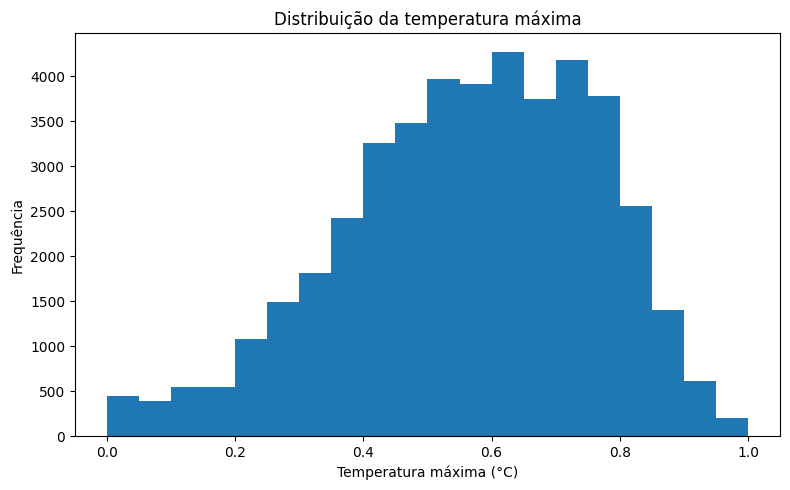

In [81]:
import matplotlib.pyplot as plt

# Distribuição da temperatura máxima
plt.figure(figsize=(8,5))
plt.hist(df_final_normalizado['temperatura_maxima_diaria'].dropna(), bins=20)
plt.title('Distribuição da temperatura máxima')
plt.xlabel('Temperatura máxima (°C)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

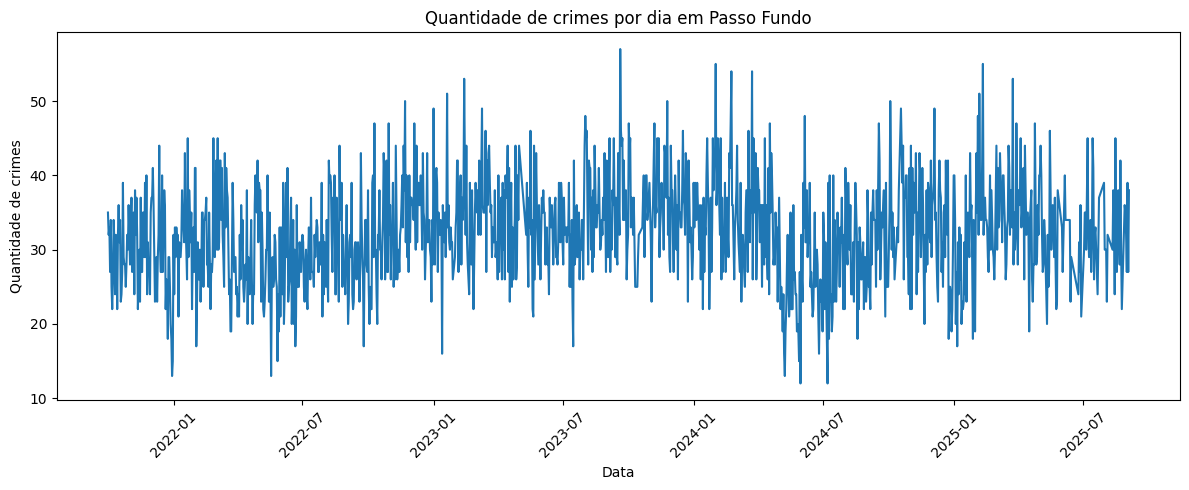

In [82]:
# Crimes por dia
dfCrimesDia = df_final_normalizado.groupby('data').size().reset_index(name='qtd_crimes')

plt.figure(figsize=(12,5))
plt.plot(dfCrimesDia['data'], dfCrimesDia['qtd_crimes'])
plt.xticks(rotation=45)
plt.title('Quantidade de crimes por dia em Passo Fundo')
plt.xlabel('Data')
plt.ylabel('Quantidade de crimes')
plt.tight_layout()
plt.show()

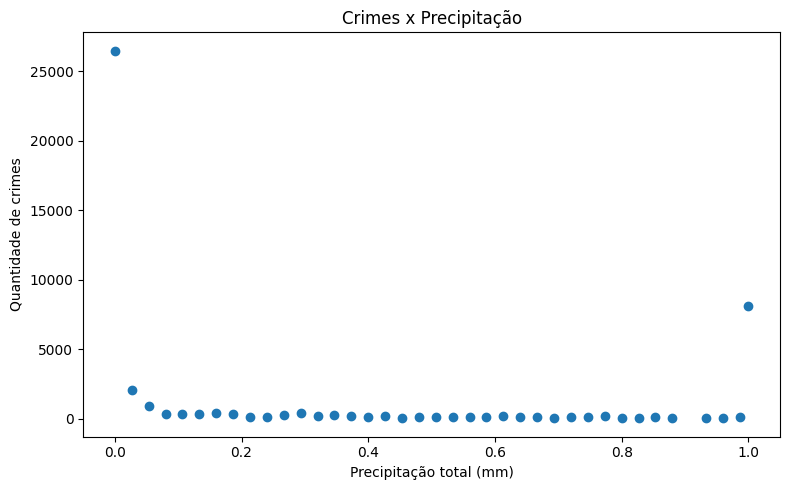

In [83]:
# Crimes x precipitação
dfCrimesPrecipitacao = df_final_normalizado.groupby('precipitacao_total_diaria').size().reset_index(name='qtd_crimes')

plt.figure(figsize=(8,5))
plt.scatter(dfCrimesPrecipitacao['precipitacao_total_diaria'], dfCrimesPrecipitacao['qtd_crimes'])
plt.title('Crimes x Precipitação')
plt.xlabel('Precipitação total (mm)')
plt.ylabel('Quantidade de crimes')
plt.tight_layout()
plt.show()